In [1]:
! pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.9 MB/s eta 0:00:00


In [2]:
import requests
import os
import json
import pandas as pd
import gzip, json
from collections import defaultdict, Counter
from torch_geometric.data import Data

In [3]:
urls = {"meta":"https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/meta_Musical_Instruments.json.gz","reviews":"https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Musical_Instruments.json.gz"}
for name, url in urls.items():
  file_name = f"{name}_Musical_Instruments.json.gz"
  if not os.path.exists(file_name):
    print(f"Downloading {file_name}...")
    response = requests.get(url)
    with open(file_name, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f"Done!")
  else:
    print(f"Already exists: {file_name}")


Done!
Done!


In [4]:
def parse_gz(path):
    with gzip.open(path, "rb") as f:
        for line in f:
            try:
                yield json.loads(line)
            except:
                try:
                    yield eval(line)
                except:
                    pass

# Count labels at each depth level
by_depth = defaultdict(Counter)

for item in parse_gz("meta_Musical_Instruments.json.gz"):
    for path in item.get("categories", []):
        for depth, label in enumerate(path):
            by_depth[depth][label] += 1

for depth in sorted(by_depth.keys()):
    print(f"\n Level {depth} ({len(by_depth[depth])} unique labels) ")
    for label, count in by_depth[depth].most_common(20):
        print(f"  {count:>6}  {label}")


 Level 0 (18 unique labels) 
   85474  Musical Instruments
   39093  CDs & Vinyl
    1354  Movies & TV
     605  Software
     107  Electronics
      65  Digital Music
      22  Video Games
       8  Cell Phones & Accessories
       7  Clothing, Shoes & Jewelry
       6  Toys & Games
       3  Sports & Outdoors
       3  Health & Personal Care
       3  Baby Products
       2  Office Products
       2  Home & Kitchen
       2  Tools & Home Improvement
       1  Arts, Crafts & Sewing
       1  Beauty

 Level 1 (83 unique labels) 
   42724  Instrument Accessories
    9390  Classical
    9096  Pop
    6509  Guitars
    5654  Live Sound & Stage
    4895  Drums & Percussion
    4879  Studio Recording Equipment
    4386  Rock
    3940  Amplifiers & Effects
    3910  Microphones & Accessories
    3054  DJ, Electronic Music & Karaoke
    2714  Band & Orchestra
    2584  Jazz
    1983  Opera & Classical Vocal
    1870  Wind & Woodwind Instruments
    1857  Stringed Instruments
    1826  World 

In [5]:
records = []

for item in parse_gz("meta_Musical_Instruments.json.gz"):
    records.append(item)

df = pd.DataFrame(records)
print(df.shape)
print(df.columns.tolist())

(84901, 9)
['asin', 'title', 'price', 'imUrl', 'salesRank', 'categories', 'related', 'brand', 'description']


In [6]:
df.head()

,asin,title,price,imUrl,salesRank,categories,related,brand,description
0,0006428320,"Six Sonatas For Two Flutes Or Violins, Volume ...",17.95,http://ecx.images-amazon.com/images/I/41EpRmh8...,{'Musical Instruments': 207315},"[[Musical Instruments, Instrument Accessories,...",NaN,NaN,NaN
1,0014072149,Double Concerto in D Minor By Johann Sebastian...,18.77,http://ecx.images-amazon.com/images/I/41m6ygCq...,{'Musical Instruments': 94593},[[Musical Instruments]],"{'also_viewed': ['B0058DK7RA'], 'buy_after_vie...",,Composer: J.S. Bach.Peters Edition.For two vio...
2,0041291905,Hal Leonard Vivaldi Four Seasons for Piano (Or...,NaN,http://ecx.images-amazon.com/images/I/41maAqSO...,{'Musical Instruments': 222972},"[[Musical Instruments, Instrument Accessories,...",NaN,NaN,Vivaldi's famous set of four violin concertos ...
3,0041913574,"Aida: Opera in Quattro Atti, Partitura -- Aida...",49.99,http://ecx.images-amazon.com/images/I/513kRMv%...,NaN,[[Musical Instruments]],NaN,NaN,444 pages. \nReprint of corrected and revised ...
4,0201891859,Nocturnes,NaN,http://ecx.images-amazon.com/images/I/41SXCAzs...,{'Musical Instruments': 171871},"[[Musical Instruments, Instrument Accessories,...",NaN,NaN,NaN


In [7]:
df.dtypes

,0
asin,object
title,object
price,float64
imUrl,object
salesRank,object
categories,object
related,object
brand,object
description,object


In [8]:
df.isnull().sum()

,0
asin,0
title,9665
price,15831
imUrl,69
salesRank,2368
categories,0
related,16558
brand,50387
description,6272


In [9]:
df['description'].notna().sum()

np.int64(78629)

In [10]:
both_missing = df['title'].isna() & df['description'].isna()
print(both_missing.sum())

1261


In [11]:
import torch
from torch_geometric.data import Data

# map every asin to an integer index
asin2idx = {asin: i for i, asin in enumerate(df['asin'])}

# build edge list
src_list = []
dst_list = []

edge_types = ['also_bought', 'also_viewed', 'bought_together', 'buy_after_viewing']

for _, row in df.iterrows():
    related = row['related']
    if not isinstance(related, dict):
        continue
    for etype in edge_types:
        for neighbor_asin in related.get(etype, []):
            if neighbor_asin in asin2idx:
                src_list.append(asin2idx[row['asin']])
                dst_list.append(asin2idx[neighbor_asin])

# add both directions
src_all = src_list + dst_list
dst_all = dst_list + src_list

#  remove duplicates
edges = set()
src_clean = []
dst_clean = []

for s, d in zip(src_all, dst_all):
    if s == d:
        continue
    if (s, d) in edges:
        continue
    edges.add((s, d))
    src_clean.append(s)
    dst_clean.append(d)


edge_index = torch.tensor([src_clean, dst_clean], dtype=torch.long)

print(f"Nodes:          {len(asin2idx)}")
print(f"Edges:          {edge_index.shape[1]}")

degree = Counter()
for src in edge_index[0].tolist():
    degree[src] += 1
print(f"Isolated nodes: {84901 - len(degree)}")
print(f"Connected nodes: {len(degree)}")

Nodes:          84901
Edges:          1870564
Isolated nodes: 24570
Connected nodes: 60331


In [12]:
from collections import Counter

leaf_freq = Counter()
for cats in df['categories']:
    for path in cats:
        if path:
            leaf_freq[path[-1]] += 1

def get_label(categories):
    if not categories:
        return None
    best_path = max(categories, key=lambda p: (len(p), leaf_freq[p[-1]]))
    capped = best_path[:4]
    return capped[-1]

df['label'] = df['categories'].apply(get_label)

print(f"Unique labels: {df['label'].nunique()}")
print(f"Null labels:   {df['label'].isna().sum()}")
print()
print(df['label'].value_counts().head(20))
print()
print(df['label'].value_counts().tail(20))

Unique labels: 512
Null labels:   0

label
General Accessories              9577
Sheet Music Folders              4697
Electric Guitar Parts            2510
Solid Body                       2449
Electric Guitar Effects          2357
Strings                          2188
Bags & Cases                     2076
Straps & Strap Locks             1821
Picks & Pick Holders             1492
Acoustic-Electric Guitars        1312
Accessories                      1282
Drumsticks, Mallets & Brushes    1246
Wireless Microphones             1245
Musical Instruments              1210
Ukuleles                         1037
LED Lighting                     1028
Drum Set Accessories             1027
Electric Guitar Amplifiers        973
Software                          964
Harmonicas                        961
Name: count, dtype: int64

label
New Orleans Jazz           1
Guinea                     1
Piano Blues                1
South & Central America    1
Caribbean & Cuba           1
Jazz Fusion        

In [13]:
label_counts = df['label'].value_counts()

print(f"Classes with >= 100 products: {(label_counts >= 100).sum()}")
print(f"Classes with >= 50 products:  {(label_counts >= 50).sum()}")
print(f"Classes with >= 10 products:  {(label_counts >= 10).sum()}")
print(f"Classes with < 10 products:   {(label_counts < 10).sum()}")
print(f"Classes with 1 product:       {(label_counts == 1).sum()}")
print()
print(f"Products in classes >= 100:   {label_counts[label_counts >= 100].sum()}")
print(f"Products in classes < 10:     {label_counts[label_counts < 10].sum()}")

Classes with >= 100 products: 142
Classes with >= 50 products:  190
Classes with >= 10 products:  309
Classes with < 10 products:   203
Classes with 1 product:       70

Products in classes >= 100:   77808
Products in classes < 10:     596


In [14]:
label_counts = df['label'].value_counts()
valid_labels = label_counts[label_counts >= 100].index

print("All 142 classes with >= 100 products:\n")
for label, count in label_counts[label_counts >= 100].items():
    print(f"  {count:>5}  {label}")

All 142 classes with >= 100 products:

   9577  General Accessories
   4697  Sheet Music Folders
   2510  Electric Guitar Parts
   2449  Solid Body
   2357  Electric Guitar Effects
   2188  Strings
   2076  Bags & Cases
   1821  Straps & Strap Locks
   1492  Picks & Pick Holders
   1312  Acoustic-Electric Guitars
   1282  Accessories
   1246  Drumsticks, Mallets & Brushes
   1245  Wireless Microphones
   1210  Musical Instruments
   1037  Ukuleles
   1028  LED Lighting
   1027  Drum Set Accessories
    973  Electric Guitar Amplifiers
    964  Software
    961  Harmonicas
    946  Bags, Cases & Covers
    886  Amplifier Accessories
    875  Folk & World
    856  Steel-string Acoustics
    827  Cymbals
    824  Instrument Cables
    810  Beginner Kits
    779  Acoustic & Classical Guitar Parts
    768  Violins
    728  Stands
    696  Mixers
    685  Condenser Microphones
    661  Mouthpieces
    617  Reeds
    609  Microphone Cables
    599  Electric Basses
    584  Sheet Music Stands
 

In [15]:
label_counts = df['label'].value_counts()
valid_labels = label_counts[label_counts >= 100].index

df_filtered = df[df['label'].isin(valid_labels)].reset_index(drop=True)

print(f"Products before: {len(df)}")
print(f"Products after:  {len(df_filtered)}")
print(f"Classes:         {df_filtered['label'].nunique()}")

Products before: 84901
Products after:  77808
Classes:         142


In [16]:
from sklearn.preprocessing import LabelEncoder

# filter
label_counts = df['label'].value_counts()
valid_labels = label_counts[label_counts >= 100].index
df_filtered = df[df['label'].isin(valid_labels)].reset_index(drop=True)

# encode labels to integers
le = LabelEncoder()
df_filtered['label_idx'] = le.fit_transform(df_filtered['label'])

print(f"Products: {len(df_filtered)}")
print(f"Classes:  {df_filtered['label_idx'].nunique()}")
print(f"\nExample:")
print(df_filtered[['title', 'label', 'label_idx']].head(5))

Products: 77808
Classes:  142

Example:
                                               title                label  \
0  Six Sonatas For Two Flutes Or Violins, Volume ...  Sheet Music Folders   
1  Double Concerto in D Minor By Johann Sebastian...  Musical Instruments   
2  Hal Leonard Vivaldi Four Seasons for Piano (Or...  Sheet Music Folders   
3  Aida: Opera in Quattro Atti, Partitura -- Aida...  Musical Instruments   
4                                          Nocturnes  Sheet Music Folders   

   label_idx  
0        107  
1         86  
2        107  
3         86  
4        107  


In [17]:
# rebuild asin2idx on filtered dataframe
asin2idx = {asin: i for i, asin in enumerate(df_filtered['asin'])}

src_list, dst_list = [], []
edge_types = ['also_bought', 'also_viewed', 'bought_together', 'buy_after_viewing']

for _, row in df_filtered.iterrows():
    related = row['related']
    if not isinstance(related, dict):
        continue
    for etype in edge_types:
        for neighbor_asin in related.get(etype, []):
            if neighbor_asin in asin2idx:
                src_list.append(asin2idx[row['asin']])
                dst_list.append(asin2idx[neighbor_asin])

src_all = src_list + dst_list
dst_all = dst_list + src_list

edges = set()
src_clean, dst_clean = [], []
for s, d in zip(src_all, dst_all):
    if s == d: continue
    if (s, d) in edges: continue
    edges.add((s, d))
    src_clean.append(s)
    dst_clean.append(d)

edge_index = torch.tensor([src_clean, dst_clean], dtype=torch.long)
print(f"Nodes: {len(asin2idx)}")
print(f"Edges: {edge_index.shape[1]}")

Nodes: 77808
Edges: 1695092


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import numpy as np

# combine title and description
df_filtered['text'] = df_filtered['title'].fillna('') + ' ' + df_filtered['description'].fillna('')
df_filtered['text'] = df_filtered['text'].str.strip()

# TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_tfidf = vectorizer.fit_transform(df_filtered['text'])

# reduce to 128 dims with SVD (same as PCA but works on sparse matrices)
svd = TruncatedSVD(n_components=128, random_state=42)
X_bow = svd.fit_transform(X_tfidf)

print(f"Feature matrix shape: {X_bow.shape}")
print(f"Explained variance:   {svd.explained_variance_ratio_.sum():.2%}")

Feature matrix shape: (77808, 128)
Explained variance:   21.19%


In [19]:
x = torch.tensor(X_bow, dtype=torch.float)
y = torch.tensor(df_filtered['label_idx'].values, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)
print(data)

Data(x=[77808, 128], edge_index=[2, 1695092], y=[77808])


In [20]:
from sklearn.model_selection import train_test_split

idx = torch.arange(len(df_filtered))

# first split off test set
idx_train_val, idx_test = train_test_split(
    idx, test_size=0.15, random_state=42,
    stratify=df_filtered['label_idx']
)

# then split train and val
idx_train, idx_val = train_test_split(
    idx_train_val, test_size=0.15/0.85, random_state=42,
    stratify=df_filtered.loc[idx_train_val.numpy(), 'label_idx']
)

data.train_mask = torch.zeros(len(df_filtered), dtype=torch.bool)
data.val_mask   = torch.zeros(len(df_filtered), dtype=torch.bool)
data.test_mask  = torch.zeros(len(df_filtered), dtype=torch.bool)

data.train_mask[idx_train] = True
data.val_mask[idx_val]     = True
data.test_mask[idx_test]   = True

print(f"Train: {data.train_mask.sum()} ({data.train_mask.sum()/len(df_filtered):.0%})")
print(f"Val:   {data.val_mask.sum()} ({data.val_mask.sum()/len(df_filtered):.0%})")
print(f"Test:  {data.test_mask.sum()} ({data.test_mask.sum()/len(df_filtered):.0%})")

Train: 54464 (70%)
Val:   11672 (15%)
Test:  11672 (15%)


In [21]:
print(data)

Data(x=[77808, 128], edge_index=[2, 1695092], y=[77808], train_mask=[77808], val_mask=[77808], test_mask=[77808])


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x):
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)
        return x

model = MLP(
    in_channels=128,      # BoW feature size
    hidden_channels=256,  # hidden layer size
    out_channels=142      # number of classes
)
print(model)

MLP(
  (lin1): Linear(in_features=128, out_features=256, bias=True)
  (lin2): Linear(in_features=256, out_features=142, bias=True)
)


In [23]:
from torch.optim import Adam

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

data = data.to(device)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x)
    pred = out.argmax(dim=1)

    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean()
    val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean()
    test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean()

    return train_acc.item(), val_acc.item(), test_acc.item()

# training loop
best_val_acc = 0
best_test_acc = 0

for epoch in range(1, 201):
    loss = train()
    train_acc, val_acc, test_acc = evaluate()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_test_acc = test_acc

    if epoch % 20 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.4f} | "
              f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

print(f"\nBest Val Acc:  {best_val_acc:.4f}")
print(f"Best Test Acc: {best_test_acc:.4f}")

Using device: cuda
Epoch  20 | Loss: 3.4868 | Train: 0.2112 | Val: 0.2116 | Test: 0.2087
Epoch  40 | Loss: 1.9525 | Train: 0.5735 | Val: 0.5683 | Test: 0.5739
Epoch  60 | Loss: 1.6727 | Train: 0.6214 | Val: 0.6154 | Test: 0.6165
Epoch  80 | Loss: 1.6692 | Train: 0.6252 | Val: 0.6172 | Test: 0.6201
Epoch 100 | Loss: 1.6550 | Train: 0.6283 | Val: 0.6218 | Test: 0.6248
Epoch 120 | Loss: 1.6461 | Train: 0.6304 | Val: 0.6234 | Test: 0.6263
Epoch 140 | Loss: 1.6383 | Train: 0.6323 | Val: 0.6265 | Test: 0.6284
Epoch 160 | Loss: 1.6364 | Train: 0.6329 | Val: 0.6256 | Test: 0.6296
Epoch 180 | Loss: 1.6332 | Train: 0.6334 | Val: 0.6274 | Test: 0.6290
Epoch 200 | Loss: 1.6282 | Train: 0.6345 | Val: 0.6292 | Test: 0.6303

Best Val Acc:  0.6292
Best Test Acc: 0.6303


In [24]:
from torch_geometric.nn import SAGEConv

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model_sage = GraphSAGE(128, 256, 142).to(device)
optimizer_sage = Adam(model_sage.parameters(), lr=0.01, weight_decay=5e-4)

def train_sage():
    model_sage.train()
    optimizer_sage.zero_grad()
    out = model_sage(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_sage.step()
    return loss.item()

@torch.no_grad()
def evaluate_sage():
    model_sage.eval()
    out = model_sage(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean()
    val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean()
    test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean()
    return train_acc.item(), val_acc.item(), test_acc.item()

best_val_acc = 0
best_test_acc = 0

for epoch in range(1, 201):
    loss = train_sage()
    train_acc, val_acc, test_acc = evaluate_sage()
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_test_acc = test_acc
    if epoch % 20 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.4f} | "
              f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

print(f"\nBest Val Acc:  {best_val_acc:.4f}")
print(f"Best Test Acc: {best_test_acc:.4f}")

Epoch  20 | Loss: 2.2755 | Train: 0.5037 | Val: 0.4979 | Test: 0.4989
Epoch  40 | Loss: 1.4246 | Train: 0.6641 | Val: 0.6557 | Test: 0.6659
Epoch  60 | Loss: 1.3987 | Train: 0.6739 | Val: 0.6647 | Test: 0.6716
Epoch  80 | Loss: 1.3694 | Train: 0.6820 | Val: 0.6720 | Test: 0.6768
Epoch 100 | Loss: 1.3625 | Train: 0.6839 | Val: 0.6739 | Test: 0.6791
Epoch 120 | Loss: 1.3563 | Train: 0.6840 | Val: 0.6734 | Test: 0.6798
Epoch 140 | Loss: 1.3551 | Train: 0.6854 | Val: 0.6759 | Test: 0.6804
Epoch 160 | Loss: 1.3511 | Train: 0.6857 | Val: 0.6743 | Test: 0.6832
Epoch 180 | Loss: 1.3480 | Train: 0.6858 | Val: 0.6759 | Test: 0.6829
Epoch 200 | Loss: 1.3470 | Train: 0.6860 | Val: 0.6757 | Test: 0.6835

Best Val Acc:  0.6778
Best Test Acc: 0.6839


In [28]:
!pip install sentence-transformers

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 95, in resolve
    result = self._result = resolver.resolve(
                            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_vendor/resolvelib/resolvers.py", line 546, in resolve
    state = resolution.resolve(requirements, max_rounds=max_rounds)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

### BERT

In [26]:
from sentence_transformers import SentenceTransformer

model_bert = SentenceTransformer('all-MiniLM-L6-v2')  # small, fast BERT

# encode all products
texts = df_filtered['text'].tolist()
X_bert = model_bert.encode(texts, batch_size=256, show_progress_bar=True)

print(f"BERT embeddings shape: {X_bert.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/304 [00:00<?, ?it/s]

BERT embeddings shape: (77808, 384)


In [29]:
from sentence_transformers import SentenceTransformer

model_bert_large = SentenceTransformer('all-mpnet-base-v2')
texts = df_filtered['text'].tolist()
X_bert_large = model_bert_large.encode(texts, batch_size=128, show_progress_bar=True)

print(f"Shape: {X_bert_large.shape}")  # should be [77808, 768]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/608 [00:00<?, ?it/s]

Shape: (77808, 768)


In [27]:
import matplotlib.pyplot as plt

def train_sage_full(x_features, in_channels, model_name="GraphSAGE",
                    epochs=300, patience=20, lr=0.01):

    # update features
    data.x = torch.tensor(x_features, dtype=torch.float).to(device)

    # model
    model = GraphSAGE(in_channels, 256, 142).to(device)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    history = {'train': [], 'val': [], 'test': [], 'loss': []}
    best_val_acc = 0
    best_test_acc = 0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # train
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # evaluate
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            pred = out.argmax(dim=1)
            train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
            val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean().item()
            test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean().item()

        history['train'].append(train_acc)
        history['val'].append(val_acc)
        history['test'].append(test_acc)
        history['loss'].append(loss.item())

        # early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if epoch % 20 == 0:
            print(f"Epoch {epoch:>3} | Loss: {loss:.4f} | "
                  f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

    print(f"\nBest Val Acc:  {best_val_acc:.4f}")
    print(f"Best Test Acc: {best_test_acc:.4f}")

    # plot
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['train'], label='Train')
    plt.plot(history['val'], label='Val')
    plt.plot(history['test'], label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Loss', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return best_val_acc, best_test_acc

 GraphSAGE + BoW 
Epoch  20 | Loss: 2.2506 | Train: 0.5062 | Val: 0.4993 | Test: 0.5004
Epoch  40 | Loss: 1.4227 | Train: 0.6651 | Val: 0.6546 | Test: 0.6670
Epoch  60 | Loss: 1.3999 | Train: 0.6743 | Val: 0.6648 | Test: 0.6719
Epoch  80 | Loss: 1.3727 | Train: 0.6813 | Val: 0.6709 | Test: 0.6784
Epoch 100 | Loss: 1.3654 | Train: 0.6843 | Val: 0.6729 | Test: 0.6808
Epoch 120 | Loss: 1.3555 | Train: 0.6842 | Val: 0.6746 | Test: 0.6809
Epoch 140 | Loss: 1.3547 | Train: 0.6860 | Val: 0.6747 | Test: 0.6835
Early stopping at epoch 154

Best Val Acc:  0.6767
Best Test Acc: 0.6825


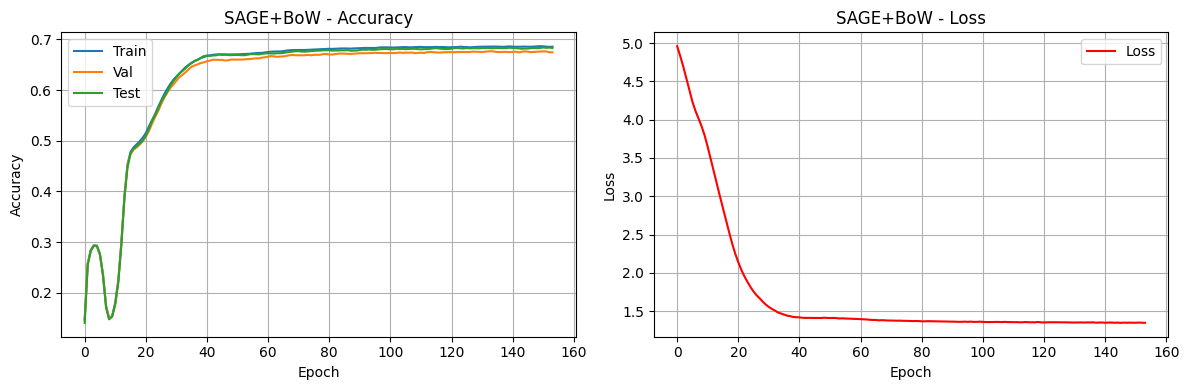

 GraphSAGE + BERT MiniLM 
Epoch  20 | Loss: 1.7027 | Train: 0.6098 | Val: 0.6051 | Test: 0.6086
Epoch  40 | Loss: 1.2785 | Train: 0.6953 | Val: 0.6864 | Test: 0.6969
Epoch  60 | Loss: 1.2064 | Train: 0.7144 | Val: 0.7045 | Test: 0.7116
Epoch  80 | Loss: 1.1784 | Train: 0.7213 | Val: 0.7095 | Test: 0.7156
Epoch 100 | Loss: 1.1593 | Train: 0.7258 | Val: 0.7125 | Test: 0.7186
Epoch 120 | Loss: 1.1520 | Train: 0.7289 | Val: 0.7144 | Test: 0.7210
Epoch 140 | Loss: 1.1467 | Train: 0.7300 | Val: 0.7151 | Test: 0.7214
Epoch 160 | Loss: 1.1421 | Train: 0.7308 | Val: 0.7160 | Test: 0.7214
Early stopping at epoch 179

Best Val Acc:  0.7179
Best Test Acc: 0.7212


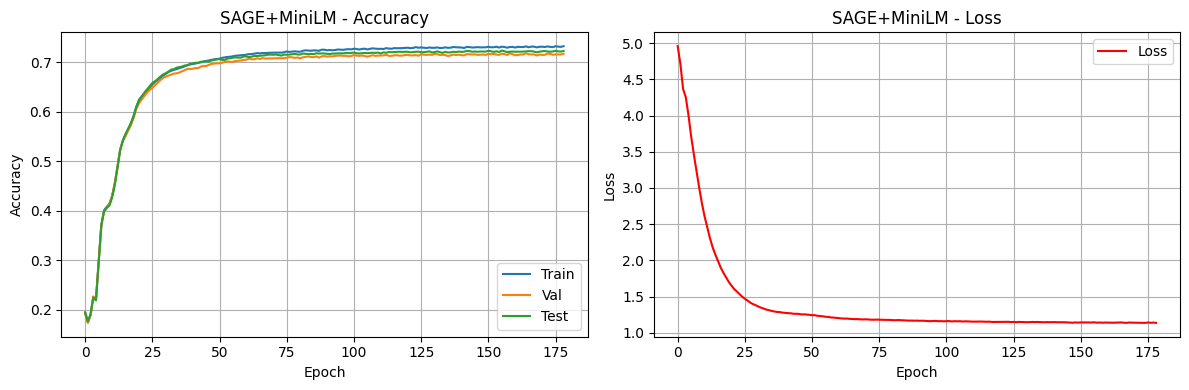

GraphSAGE + BERT large
Epoch  20 | Loss: 1.5597 | Train: 0.6380 | Val: 0.6354 | Test: 0.6426
Epoch  40 | Loss: 1.2505 | Train: 0.7066 | Val: 0.6956 | Test: 0.7058
Epoch  60 | Loss: 1.1521 | Train: 0.7285 | Val: 0.7181 | Test: 0.7224
Epoch  80 | Loss: 1.1310 | Train: 0.7329 | Val: 0.7192 | Test: 0.7248
Epoch 100 | Loss: 1.1188 | Train: 0.7355 | Val: 0.7216 | Test: 0.7260
Epoch 120 | Loss: 1.1093 | Train: 0.7341 | Val: 0.7190 | Test: 0.7259
Early stopping at epoch 137

Best Val Acc:  0.7240
Best Test Acc: 0.7288


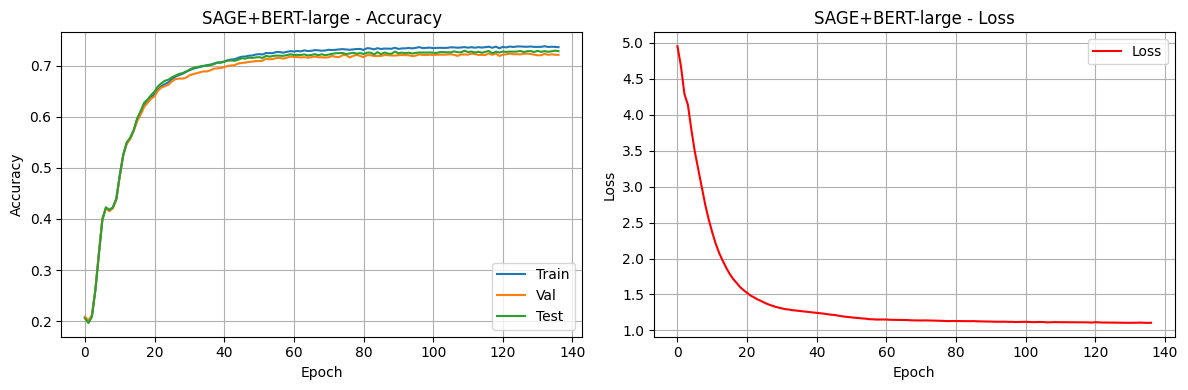

In [30]:
# BoW baseline
print(" GraphSAGE + BoW ")
val_bow, test_bow = train_sage_full(X_bow, in_channels=128, model_name="SAGE+BoW")

# BERT small (MiniLM)
print(" GraphSAGE + BERT MiniLM ")
val_minilm, test_minilm = train_sage_full(X_bert, in_channels=384, model_name="SAGE+MiniLM")

# BERT large (mpnet)
print("GraphSAGE + BERT large")
val_bert, test_bert = train_sage_full(X_bert_large, in_channels=768, model_name="SAGE+BERT-large")

### CLIP

In [34]:
from transformers import CLIPTokenizer, CLIPTextModel
import torch
import numpy as np

# use CLIPTextModel instead of CLIPModel
clip_text_model = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

texts = df_filtered['text'].tolist()
X_clip_text = []

clip_text_model.eval()
batch_size = 256

with torch.no_grad():
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = clip_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=77,
            return_tensors="pt"
        ).to(device)
        outputs = clip_text_model(**inputs)
        # extract pooled output → the [CLS] token embedding
        embeddings = outputs.pooler_output  # ← this is the tensor
        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
        X_clip_text.append(embeddings.cpu().numpy())
        if i % 10000 == 0:
            print(f"Processed {i}/{len(texts)}")

X_clip_text = np.vstack(X_clip_text)
print(f"CLIP text embeddings shape: {X_clip_text.shape}")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
visual_projection.weight                                       | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.pre_layrnorm.bias                                 | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

Processed 0/77808
CLIP text embeddings shape: (77808, 512)


 GraphSAGE + CLIP text 
Epoch  20 | Loss: 1.6177 | Train: 0.6292 | Val: 0.6229 | Test: 0.6286
Epoch  40 | Loss: 1.2284 | Train: 0.7060 | Val: 0.6960 | Test: 0.7062
Epoch  60 | Loss: 1.1509 | Train: 0.7262 | Val: 0.7180 | Test: 0.7242
Epoch  80 | Loss: 1.1261 | Train: 0.7302 | Val: 0.7202 | Test: 0.7277
Epoch 100 | Loss: 1.1093 | Train: 0.7353 | Val: 0.7227 | Test: 0.7300
Epoch 120 | Loss: 1.1013 | Train: 0.7372 | Val: 0.7246 | Test: 0.7302
Epoch 140 | Loss: 1.1003 | Train: 0.7383 | Val: 0.7242 | Test: 0.7316
Epoch 160 | Loss: 1.0940 | Train: 0.7395 | Val: 0.7264 | Test: 0.7324
Early stopping at epoch 173

Best Val Acc:  0.7282
Best Test Acc: 0.7316


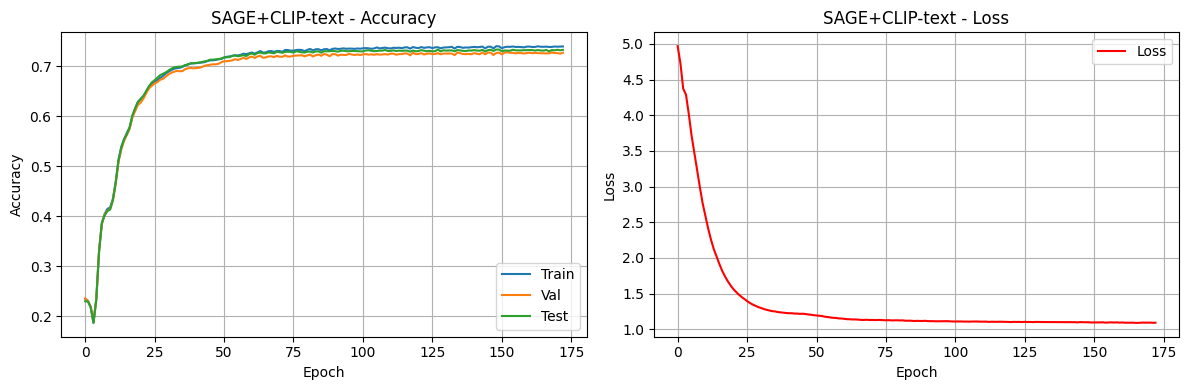

In [35]:
print(" GraphSAGE + CLIP text ")
val_clip, test_clip = train_sage_full(
    X_clip_text,
    in_channels=512,
    model_name="SAGE+CLIP-text"
)

In [41]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

def get_qwen_embeddings(model_name, texts, batch_size=64):
    print(f"Loading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, torch_dtype=torch.float16).to(device)
    model.eval()

    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt"
            ).to(device)
            outputs = model(**inputs)
            # mean pooling
            mask = inputs['attention_mask'].unsqueeze(-1).float()
            emb = (outputs.last_hidden_state * mask).sum(1) / mask.sum(1)
            emb = emb / emb.norm(dim=-1, keepdim=True)
            embeddings.append(emb.cpu().float().numpy())
            if i % 5000 == 0:
                print(f"  {i}/{len(texts)}")

    return np.vstack(embeddings)

texts = df_filtered['text'].tolist()
X_qwen_06b = get_qwen_embeddings("Qwen/Qwen3-Embedding-0.6B", texts)
print(f"Shape: {X_qwen_06b.shape}")

Loading Qwen/Qwen3-Embedding-0.6B...


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  0/77808


KeyboardInterrupt: 